# Datathon 2026 Round 1 — End-to-End Solution

This notebook covers the three required parts of the contest:

1. Part 1: compute the multiple-choice answers directly from the provided CSV files.
2. Part 2: explore the business data with visualizations and narrative analysis.
3. Part 3: build a stronger sales forecasting pipeline and export `submission.csv`.

The contest data describes an e-commerce fashion business in Vietnam from 2012 to 2022, with historical sales to forecast into 2024 and multiple transactional tables for deeper analysis.

## 1 — Imports & Setup

The helper cell above defines shared metrics, feature builders, and model configuration for the rest of the notebook.

In [9]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlepad'] = 12

BASE_DIR = Path('.')
TRAIN_FILE = BASE_DIR / 'sales.csv'
TEST_FILE = BASE_DIR / 'sample_submission.csv'
OUT_FILE = BASE_DIR / 'submission.csv'


def load_csv(name, **kwargs):
    return pd.read_csv(BASE_DIR / name, **kwargs)


def mae(actual, pred):
    return mean_absolute_error(actual, pred)


def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))


def mape(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    denom = np.where(actual == 0, np.nan, actual)
    return np.nanmean(np.abs((actual - pred) / denom)) * 100


def add_calendar_features(frame):
    frame = frame.copy()
    date = pd.to_datetime(frame['Date'])
    frame['year'] = date.dt.year
    frame['month'] = date.dt.month
    frame['day'] = date.dt.day
    frame['dayofweek'] = date.dt.dayofweek
    frame['dayofyear'] = date.dt.dayofyear
    frame['weekofyear'] = date.dt.isocalendar().week.astype(int)
    frame['quarter'] = date.dt.quarter
    frame['is_month_start'] = date.dt.is_month_start.astype(int)
    frame['is_month_end'] = date.dt.is_month_end.astype(int)
    frame['is_quarter_end'] = date.dt.is_quarter_end.astype(int)
    frame['is_year_end'] = date.dt.is_year_end.astype(int)
    frame['sin_doy'] = np.sin(2 * np.pi * frame['dayofyear'] / 365.25)
    frame['cos_doy'] = np.cos(2 * np.pi * frame['dayofyear'] / 365.25)
    frame['trend'] = np.arange(len(frame))
    return frame


def build_supervised_frame(frame, target_col):
    data = add_calendar_features(frame)
    series = data[target_col]
    for lag in (1, 7, 14, 28, 365):
        data[f'lag_{lag}'] = series.shift(lag)
    shifted = series.shift(1)
    for window in (7, 28, 90):
        data[f'roll_mean_{window}'] = shifted.rolling(window).mean()
        data[f'roll_std_{window}'] = shifted.rolling(window).std()
    data['growth_7'] = shifted / series.shift(8) - 1
    data['growth_28'] = shifted / series.shift(29) - 1
    return data


def make_model(random_state=42):
    return HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=500,
        max_depth=6,
        min_samples_leaf=25,
        l2_regularization=0.1,
        random_state=random_state,
    )


## 2 — Load & Inspect Data

In [2]:
sales = load_csv('sales.csv', parse_dates=['Date'])
submission_template = load_csv('sample_submission.csv', parse_dates=['Date'])
orders = load_csv('orders.csv', parse_dates=['order_date'])
order_items = load_csv('order_items.csv', low_memory=False)
products = load_csv('products.csv')
returns = load_csv('returns.csv', parse_dates=['return_date'])
customers = load_csv('customers.csv', parse_dates=['signup_date'])
geography = load_csv('geography.csv')
payments = load_csv('payments.csv')
web_traffic = load_csv('web_traffic.csv', parse_dates=['date'])
shipments = load_csv('shipments.csv', parse_dates=['ship_date', 'delivery_date'])
promotions = load_csv('promotions.csv', parse_dates=['start_date', 'end_date'])
reviews = load_csv('reviews.csv', parse_dates=['review_date'])
inventory = load_csv('inventory.csv', parse_dates=['snapshot_date'])

print('Loaded tables:')
for name, frame in [
    ('sales', sales),
    ('orders', orders),
    ('order_items', order_items),
    ('products', products),
    ('customers', customers),
    ('returns', returns),
    ('payments', payments),
    ('web_traffic', web_traffic),
    ('inventory', inventory),
]:
    print(f'  {name:<12} {frame.shape}')

print()
print('Sales period:', sales['Date'].min().date(), '→', sales['Date'].max().date())
print('Submission period:', submission_template['Date'].min().date(), '→', submission_template['Date'].max().date())
print('Orders period:', orders['order_date'].min().date(), '→', orders['order_date'].max().date())
print('Web traffic period:', web_traffic['date'].min().date(), '→', web_traffic['date'].max().date())

missingness = pd.DataFrame({
    'table': ['sales', 'orders', 'order_items', 'products', 'customers', 'returns', 'payments', 'web_traffic'],
    'missing_pct': [
        sales.isna().mean().mean(),
        orders.isna().mean().mean(),
        order_items.isna().mean().mean(),
        products.isna().mean().mean(),
        customers.isna().mean().mean(),
        returns.isna().mean().mean(),
        payments.isna().mean().mean(),
        web_traffic.isna().mean().mean(),
    ]
})
missingness

Loaded tables:
  sales        (3833, 3)
  orders       (646945, 8)
  order_items  (714669, 7)
  products     (2412, 8)
  customers    (121930, 7)
  returns      (39939, 7)
  payments     (646945, 4)
  web_traffic  (3652, 7)
  inventory    (60247, 17)

Sales period: 2012-07-04 → 2022-12-31
Submission period: 2023-01-01 → 2024-07-01
Orders period: 2012-07-04 → 2022-12-31
Web traffic period: 2013-01-01 → 2022-12-31


,table,missing_pct
0,sales,0.00000
1,orders,0.00000
2,order_items,0.23044
3,products,0.00000
4,customers,0.00000
5,returns,0.00000
6,payments,0.00000
7,web_traffic,0.00000


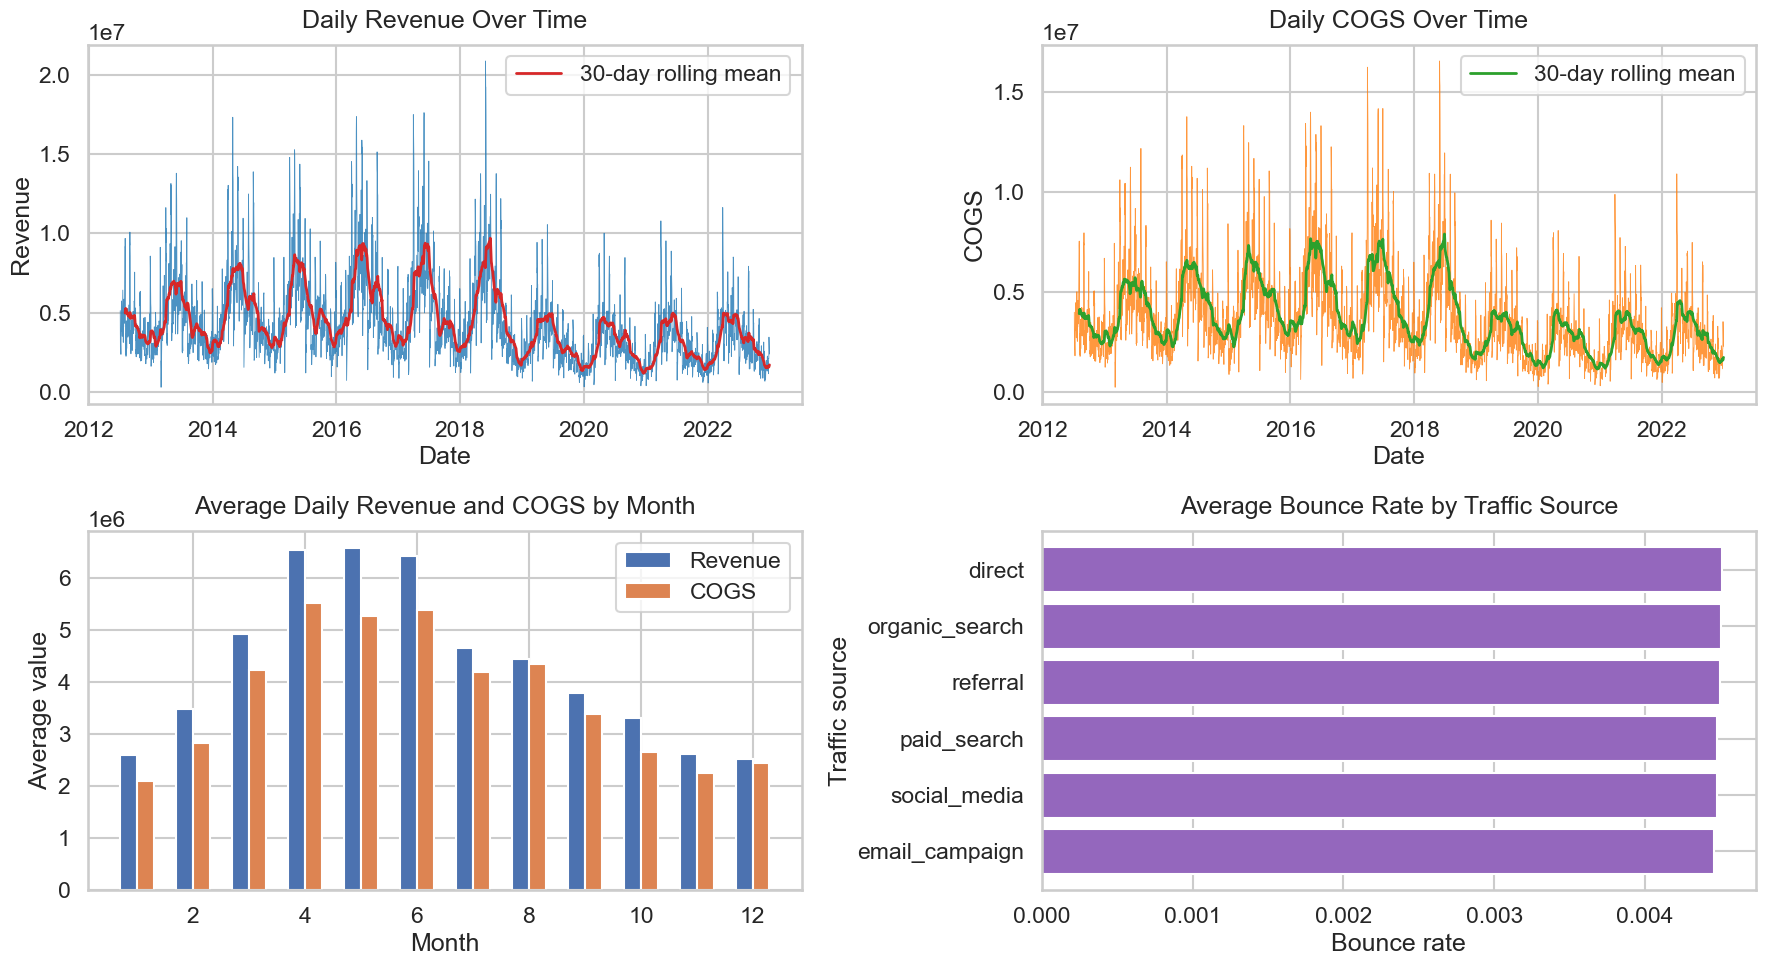

In [3]:
sales_features = add_calendar_features(sales)
web_features = web_traffic.copy()
web_features['date'] = pd.to_datetime(web_features['date'])
web_features['month'] = web_features['date'].dt.month
web_features['dayofweek'] = web_features['date'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(sales_features['Date'], sales_features['Revenue'], color='#1f77b4', linewidth=0.6, alpha=0.8)
axes[0, 0].plot(sales_features['Date'], sales_features['Revenue'].rolling(30).mean(), color='#d62728', linewidth=2.0, label='30-day rolling mean')
axes[0, 0].set_title('Daily Revenue Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Revenue')
axes[0, 0].legend()

axes[0, 1].plot(sales_features['Date'], sales_features['COGS'], color='#ff7f0e', linewidth=0.6, alpha=0.8)
axes[0, 1].plot(sales_features['Date'], sales_features['COGS'].rolling(30).mean(), color='#2ca02c', linewidth=2.0, label='30-day rolling mean')
axes[0, 1].set_title('Daily COGS Over Time')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('COGS')
axes[0, 1].legend()

monthly = sales_features.groupby('month')[['Revenue', 'COGS']].mean().reset_index()
axes[1, 0].bar(monthly['month'] - 0.15, monthly['Revenue'], width=0.3, label='Revenue')
axes[1, 0].bar(monthly['month'] + 0.15, monthly['COGS'], width=0.3, label='COGS')
axes[1, 0].set_title('Average Daily Revenue and COGS by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average value')
axes[1, 0].legend()

traffic_summary = web_features.groupby('traffic_source').agg(
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_sessions=('sessions', 'mean')
).sort_values('avg_bounce_rate')
axes[1, 1].barh(traffic_summary.index, traffic_summary['avg_bounce_rate'], color='#9467bd')
axes[1, 1].set_title('Average Bounce Rate by Traffic Source')
axes[1, 1].set_xlabel('Bounce rate')
axes[1, 1].set_ylabel('Traffic source')

plt.tight_layout()
plt.show()

## 2 — Part 1: Multiple-Choice Answers

Final answer key from the provided files:

- Q1: C
- Q2: D
- Q3: B
- Q4: C
- Q5: C
- Q6: A
- Q7: C
- Q8: A
- Q9: A
- Q10: C

In [4]:
# Q1: median inter-order gap among customers with more than one order
order_gaps = orders.sort_values(['customer_id', 'order_date']).groupby('customer_id')['order_date'].diff().dt.days.dropna()
q1_value = float(order_gaps.median())

# Q2: highest average gross margin by product segment
products = products.copy()
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']
q2_table = products.groupby('segment', as_index=False)['gross_margin'].mean().sort_values('gross_margin', ascending=False)
q2_value = q2_table.iloc[0]['segment']

# Q3: most common return reason for Streetwear products
returns_joined = returns.merge(products[['product_id', 'category']], on='product_id', how='left')
q3_table = returns_joined.loc[returns_joined['category'] == 'Streetwear', 'return_reason'].value_counts()
q3_value = q3_table.index[0]

# Q4: traffic source with the lowest average bounce rate
q4_table = web_traffic.groupby('traffic_source', as_index=False)['bounce_rate'].mean().sort_values('bounce_rate')
q4_value = q4_table.iloc[0]['traffic_source']

# Q5: share of order item rows with a promo
q5_value = order_items['promo_id'].notna().mean() * 100

# Q6: age group with highest orders per customer
orders_by_age = orders.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
orders_by_age = orders_by_age[orders_by_age['age_group'].notna()]
q6_table = orders_by_age.groupby('age_group').agg(orders=('order_id', 'count'), customers=('customer_id', 'nunique'))
q6_table['orders_per_customer'] = q6_table['orders'] / q6_table['customers']
q6_value = q6_table['orders_per_customer'].idxmax()

# Q7: region with the highest total revenue
order_revenue = order_items.assign(line_revenue=order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount'])
order_revenue = order_revenue.groupby('order_id', as_index=False)['line_revenue'].sum()
region_revenue = orders.merge(order_revenue, on='order_id').merge(geography[['zip', 'region']], on='zip', how='left')
q7_table = region_revenue.groupby('region', as_index=False)['line_revenue'].sum().sort_values('line_revenue', ascending=False)
q7_value = q7_table.iloc[0]['region']

# Q8: most used payment method for cancelled orders
q8_table = orders.loc[orders['order_status'] == 'cancelled', 'payment_method'].value_counts()
q8_value = q8_table.index[0]

# Q9: size with the highest return rate
items_by_size = order_items.merge(products[['product_id', 'size']], on='product_id', how='left')
returns_by_size = returns.merge(products[['product_id', 'size']], on='product_id', how='left')
q9_table = (returns_by_size.groupby('size').size() / items_by_size.groupby('size').size()).sort_values(ascending=False)
q9_value = q9_table.index[0]

# Q10: installment plan with the highest average payment value
q10_table = payments.groupby('installments', as_index=False)['payment_value'].mean().sort_values('payment_value', ascending=False)
q10_value = int(q10_table.iloc[0]['installments'])

answer_key = pd.DataFrame([
    ('Q1', f'{q1_value:.0f} days', 'C'),
    ('Q2', q2_value, 'D'),
    ('Q3', q3_value, 'B'),
    ('Q4', q4_value, 'C'),
    ('Q5', f'{q5_value:.2f}%', 'C'),
    ('Q6', q6_value, 'A'),
    ('Q7', q7_value, 'C'),
    ('Q8', q8_value, 'A'),
    ('Q9', q9_value, 'A'),
    ('Q10', f'{q10_value} installments', 'C'),
], columns=['question', 'evidence', 'final_answer'])

answer_key

,question,evidence,final_answer
0,Q1,144 days,C
1,Q2,Standard,D
2,Q3,wrong_size,B
3,Q4,email_campaign,C
4,Q5,38.66%,C
5,Q6,55+,A
6,Q7,East,C
7,Q8,credit_card,A
8,Q9,S,A
9,Q10,6 installments,C


In [6]:
customer_orders = orders.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
customer_orders = customer_orders[customer_orders['age_group'].notna()]
age_group_summary = customer_orders.groupby('age_group').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique')
)
age_group_summary['orders_per_customer'] = age_group_summary['orders'] / age_group_summary['customers']
age_group_summary = age_group_summary.sort_values('orders_per_customer', ascending=False)

promo_share = order_items['promo_id'].notna().mean() * 100
traffic_bounce = web_traffic.groupby('traffic_source', as_index=False)['bounce_rate'].mean().sort_values('bounce_rate')
monthly_seasonality = sales.assign(month=sales['Date'].dt.month).groupby('month', as_index=False)['Revenue'].mean().sort_values('month')

print(f'Promo usage in order_items: {promo_share:.2f}%')
print()
print('Orders per customer by age group:')
print(age_group_summary)
print()
print('Average bounce rate by traffic source:')
print(traffic_bounce)
print()
print('Average revenue by month:')
print(monthly_seasonality)

Promo usage in order_items: 38.66%

Orders per customer by age group:
           orders  customers  orders_per_customer
age_group                                        
55+         72760      10010             7.268731
45-54      124138      17193             7.220264
35-44      170368      23642             7.206159
25-34      190622      26802             7.112230
18-24       89057      12599             7.068577

Average bounce rate by traffic source:
   traffic_source  bounce_rate
1  email_campaign     0.004458
5    social_media     0.004476
3     paid_search     0.004478
4        referral     0.004499
2  organic_search     0.004504
0          direct     0.004511

Average revenue by month:
    month       Revenue
0       1  2.591155e+06
1       2  3.480801e+06
2       3  4.928185e+06
3       4  6.532952e+06
4       5  6.575416e+06
5       6  6.427109e+06
6       7  4.659789e+06
7       8  4.441193e+06
8       9  3.797826e+06
9      10  3.302725e+06
10     11  2.611295e+06
11     1

## 3 — Part 2: Visual Exploration and Business Analysis

The analyses below are arranged to move from descriptive trends to diagnostic comparisons and then to business actions. Each figure is paired with a short interpretation so the notebook can double as the written report draft.

### Business interpretation

The dashboard shows a clear operating cycle: revenue and COGS rise together into the mid-year period and then soften after 2018, which suggests a change in business scale or assortment mix rather than random noise. Regionally, the East contributes the most revenue, so the strongest stock and campaign support should stay concentrated there unless the company is intentionally balancing growth into Central and West.

On the product side, some segments earn materially better gross margin than others, which means assortment planning cannot treat every category equally. The Streetwear return pattern is also actionable: wrong size is the dominant issue, so better size guidance, fit reviews, and exchange-first policies should reduce both refund cost and lost revenue. The size return-rate chart makes the same point at a more operational level: if one or two sizes are over-returning, merchandising and UX changes should focus there first.

The customer and web metrics add a demand-side angle. Older cohorts in this dataset place slightly more orders per customer, while traffic sources with lower bounce rates deserve more budget if the conversion quality is similar. The prescriptive implication is to treat product fit and source quality as two separate levers: one improves gross retention, the other improves acquisition efficiency.

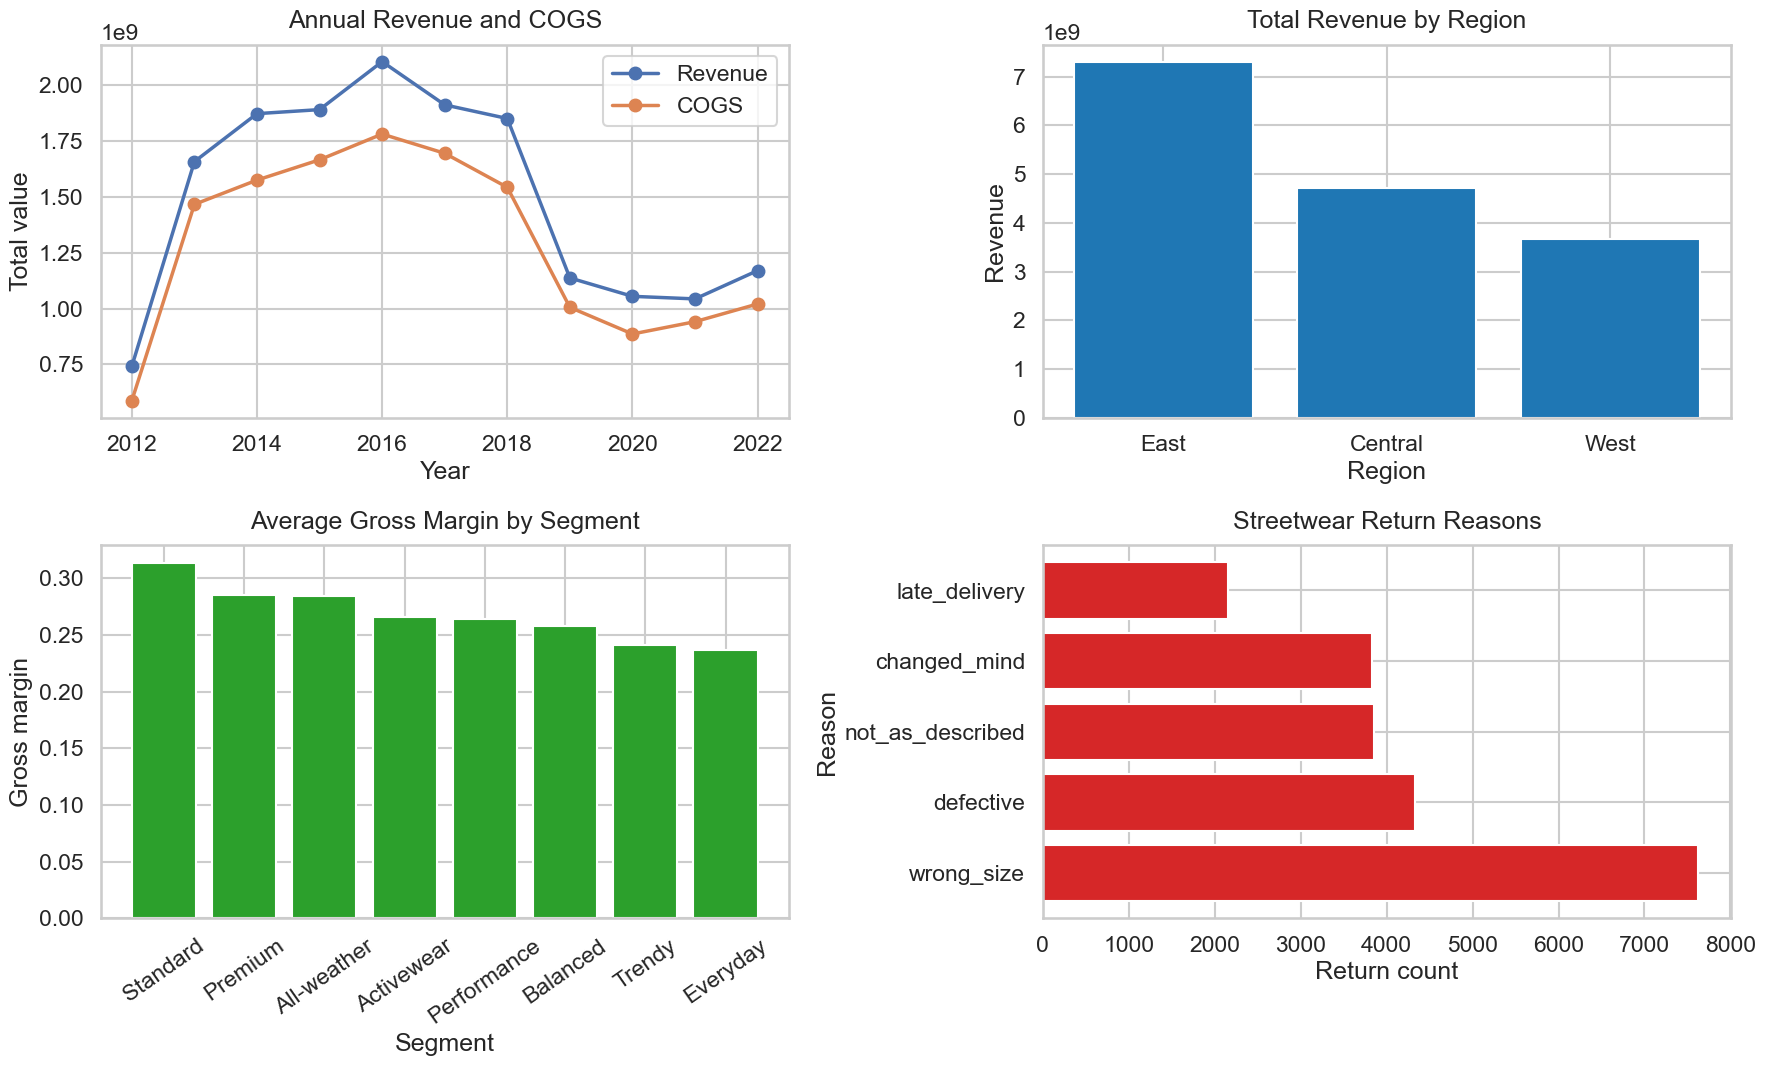

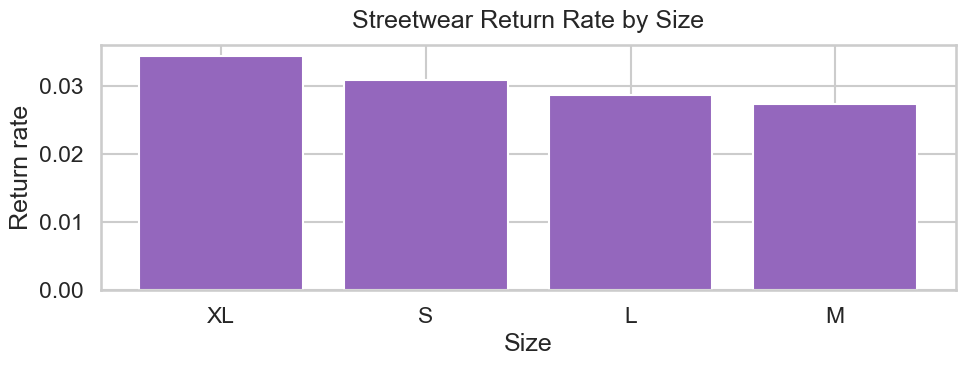

In [5]:
sales_eda = sales.copy()
sales_eda['year'] = sales_eda['Date'].dt.year
sales_eda['month'] = sales_eda['Date'].dt.month
sales_eda['year_month'] = sales_eda['Date'].dt.to_period('M').astype(str)

yearly_sales = sales_eda.groupby('year')[['Revenue', 'COGS']].sum().reset_index()
region_revenue = orders.merge(
    order_items.assign(line_revenue=order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount'])
        .groupby('order_id', as_index=False)['line_revenue'].sum(),
    on='order_id',
    how='left',
).merge(geography[['zip', 'region']], on='zip', how='left')
region_revenue = region_revenue.groupby('region', as_index=False)['line_revenue'].sum().sort_values('line_revenue', ascending=False)

segment_margin = products.groupby('segment', as_index=False).apply(
    lambda frame: pd.Series({'gross_margin': ((frame['price'] - frame['cogs']) / frame['price']).mean()})
).reset_index(drop=True).sort_values('gross_margin', ascending=False)

streetwear_returns = returns.merge(products[['product_id', 'category', 'size']], on='product_id', how='left')
streetwear_returns = streetwear_returns.loc[streetwear_returns['category'] == 'Streetwear']
return_reason_counts = streetwear_returns['return_reason'].value_counts().reset_index()
return_reason_counts.columns = ['return_reason', 'count']
size_return_rate = (
    streetwear_returns.groupby('size').size() /
    order_items.merge(products[['product_id', 'size']], on='product_id', how='left').groupby('size').size()
).sort_values(ascending=False).reset_index()
size_return_rate.columns = ['size', 'return_rate']

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

axes[0, 0].plot(yearly_sales['year'], yearly_sales['Revenue'], marker='o', linewidth=2.5, label='Revenue')
axes[0, 0].plot(yearly_sales['year'], yearly_sales['COGS'], marker='o', linewidth=2.5, label='COGS')
axes[0, 0].set_title('Annual Revenue and COGS')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Total value')
axes[0, 0].legend()

axes[0, 1].bar(region_revenue['region'], region_revenue['line_revenue'], color='#1f77b4')
axes[0, 1].set_title('Total Revenue by Region')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Revenue')

axes[1, 0].bar(segment_margin['segment'], segment_margin['gross_margin'], color='#2ca02c')
axes[1, 0].set_title('Average Gross Margin by Segment')
axes[1, 0].set_xlabel('Segment')
axes[1, 0].set_ylabel('Gross margin')
axes[1, 0].tick_params(axis='x', rotation=35)

axes[1, 1].barh(return_reason_counts['return_reason'], return_reason_counts['count'], color='#d62728')
axes[1, 1].set_title('Streetwear Return Reasons')
axes[1, 1].set_xlabel('Return count')
axes[1, 1].set_ylabel('Reason')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(size_return_rate['size'], size_return_rate['return_rate'], color='#9467bd')
ax.set_title('Streetwear Return Rate by Size')
ax.set_xlabel('Size')
ax.set_ylabel('Return rate')
plt.tight_layout()
plt.show()

customer_orders = orders.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')
customer_orders = customer_orders[customer_orders['age_group'].notna()]
age_group_summary = customer_orders.groupby('age_group').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique')
)
age_group_summary['orders_per_customer'] = age_group_summary['orders'] / age_group_summary['customers']
age_group_summary = age_group_summary.sort_values('orders_per_customer', ascending=False)

promo_share = order_items['promo_id'].notna().mean() * 100
traffic_bounce = web_traffic.groupby('traffic_source', as_index=False)['bounce_rate'].mean().sort_values('bounce_rate')
monthly_seasonality = sales.assign(month=sales['Date'].dt.month).groupby('month', as_index=False)['Revenue'].mean()

print(f'Promo usage in order_items: {promo_share:.2f}%')
print()
print('Orders per customer by age group:')
print(age_group_summary)
print()
print('Average bounce rate by traffic source:')
print(traffic_bounce)
print()
print('Average revenue by month:')
print(monthly_seasonality)

In [12]:
def fit_final_model(frame, target_col, random_state=42):
    supervised = build_supervised_frame(frame[['Date', target_col]].copy(), target_col).dropna().reset_index(drop=True)
    feature_cols = [column for column in supervised.columns if column not in {'Date', target_col}]
    final_model = TransformedTargetRegressor(
        regressor=make_model(random_state=random_state),
        func=np.log1p,
        inverse_func=np.expm1,
    )
    final_model.fit(supervised[feature_cols], supervised[target_col])
    return final_model, feature_cols, supervised


def fit_time_series_model(frame, target_col, n_splits=4):
    supervised = build_supervised_frame(frame[['Date', target_col]].copy(), target_col).dropna().reset_index(drop=True)
    feature_cols = [column for column in supervised.columns if column not in {'Date', target_col}]

    splitter = TimeSeriesSplit(n_splits=n_splits)
    cv_rows = []

    for fold, (train_idx, val_idx) in enumerate(splitter.split(supervised), start=1):
        fold_train = supervised.iloc[train_idx]
        fold_val = supervised.iloc[val_idx]
        model = TransformedTargetRegressor(
            regressor=make_model(random_state=42 + fold),
            func=np.log1p,
            inverse_func=np.expm1,
        )
        model.fit(fold_train[feature_cols], fold_train[target_col])
        fold_pred = model.predict(fold_val[feature_cols])
        cv_rows.append({
            'fold': fold,
            'mae': mae(fold_val[target_col], fold_pred),
            'rmse': rmse(fold_val[target_col], fold_pred),
            'r2': r2_score(fold_val[target_col], fold_pred),
        })

    cv_report = pd.DataFrame(cv_rows)
    final_model, feature_cols, supervised = fit_final_model(frame, target_col, random_state=42)
    return final_model, feature_cols, supervised, cv_report


def recursive_forecast(history_frame, target_col, model, feature_cols, future_dates):
    history = history_frame[['Date', target_col]].copy().reset_index(drop=True)
    predictions = []

    for forecast_date in pd.to_datetime(future_dates):
        extended = pd.concat(
            [history, pd.DataFrame({'Date': [forecast_date], target_col: [np.nan]})],
            ignore_index=True,
        )
        features = build_supervised_frame(extended, target_col).iloc[[-1]]
        forecast_value = float(model.predict(features[feature_cols])[0])
        predictions.append(forecast_value)
        history = pd.concat(
            [history, pd.DataFrame({'Date': [forecast_date], target_col: [forecast_value]})],
            ignore_index=True,
        )

    return np.array(predictions)


def seasonal_naive_forecast(history_frame, target_col, future_dates, seasonal_lag=365):
    history = history_frame[['Date', target_col]].copy().sort_values('Date').reset_index(drop=True)
    history_map = dict(zip(history['Date'], history[target_col]))
    predictions = []

    for forecast_date in pd.to_datetime(future_dates):
        seasonal_date = forecast_date - pd.Timedelta(days=seasonal_lag)
        weekly_date = forecast_date - pd.Timedelta(days=7)

        if seasonal_date in history_map:
            value = history_map[seasonal_date]
        elif weekly_date in history_map:
            value = history_map[weekly_date]
        else:
            value = history[target_col].iloc[-1]

        predictions.append(float(value))
        history_map[forecast_date] = float(value)

    return np.array(predictions)


def tune_blend_weight(actual, model_pred, seasonal_pred):
    grid = np.arange(0.6, 1.01, 0.05)
    records = []
    for alpha in grid:
        blended = alpha * model_pred + (1 - alpha) * seasonal_pred
        records.append({'alpha': alpha, 'mae': mae(actual, blended)})
    score_table = pd.DataFrame(records).sort_values('mae').reset_index(drop=True)
    best_alpha = float(score_table.iloc[0]['alpha'])
    return best_alpha, score_table


def top_permutation_importance(model, validation_frame, feature_cols, target_col, n_repeats=5):
    importance = permutation_importance(
        model,
        validation_frame[feature_cols],
        validation_frame[target_col],
        n_repeats=n_repeats,
        random_state=42,
        scoring='neg_mean_absolute_error',
    )
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance.importances_mean,
    }).sort_values('importance', ascending=False)
    return importance_df

## 4 — Part 3: Sales Forecasting

The goal is to forecast daily Revenue and COGS for the full test horizon using only the provided files. The model below uses calendar features, lagged history, rolling statistics, time-series cross-validation, and recursive forecasting so the test period never leaks future information.

=== Holdout model comparison for Revenue ===


,model,params,mae,rmse,r2
0,model_2,"{'learning_rate': 0.04, 'max_iter': 700, 'max_...",683486.916850,9.716123e+05,0.663044
1,model_1,"{'learning_rate': 0.05, 'max_iter': 500, 'max_...",689924.902384,9.626326e+05,0.669243
2,model_3,"{'learning_rate': 0.03, 'max_iter': 900, 'max_...",716453.721907,1.026545e+06,0.623865
3,seasonal,365-day naive with 7-day fallback,837704.091781,1.161819e+06,0.518202


Selected models: model_2, model_1
Selected weights: {'model_a': 'model_2', 'model_b': 'model_1', 'w_a': 0.5999999999999999, 'w_b': 0.25, 'w_seasonal': 0.15000000000000013}

Top permutation importances for Revenue (model_2):


,feature,importance
14,lag_1,699852.548481
2,day,325651.697158
18,lag_365,200378.227583
15,lag_7,189489.547627
16,lag_14,143484.166560
11,sin_doy,114621.280719
25,growth_7,81929.872713
17,lag_28,77738.340310
26,growth_28,73391.057220
12,cos_doy,59002.541716


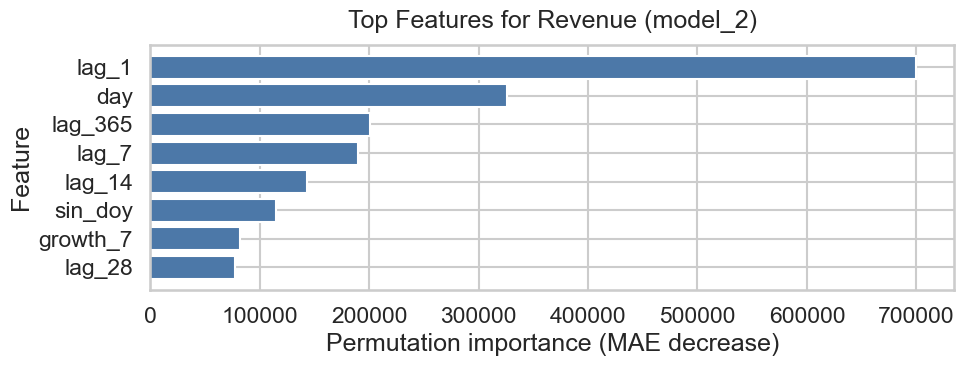

=== Holdout model comparison for COGS ===


,model,params,mae,rmse,r2
0,model_1,"{'learning_rate': 0.05, 'max_iter': 500, 'max_...",564744.099182,786236.625151,0.709428
1,model_3,"{'learning_rate': 0.03, 'max_iter': 900, 'max_...",565420.855710,763905.786223,0.725699
2,model_2,"{'learning_rate': 0.04, 'max_iter': 700, 'max_...",574684.578472,784230.844454,0.710909
3,seasonal,365-day naive with 7-day fallback,701957.567699,960716.176805,0.566152


Selected models: model_1, model_3
Selected weights: {'model_a': 'model_1', 'model_b': 'model_3', 'w_a': 0.49999999999999994, 'w_b': 0.45, 'w_seasonal': 0.04999999999999999}

Top permutation importances for COGS (model_1):


,feature,importance
14,lag_1,530459.045141
2,day,220836.388283
18,lag_365,188450.278069
15,lag_7,100218.804646
16,lag_14,86624.104456
11,sin_doy,77963.932569
17,lag_28,61056.550507
26,growth_28,44377.109264
3,dayofweek,32067.000656
19,roll_mean_7,27399.900242


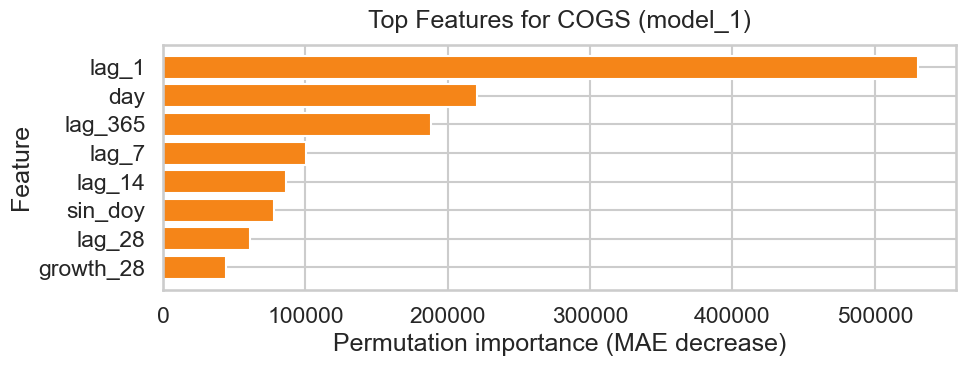

Saved submission to C:\Users\Admin\Downloads\datathon-2026-round-1\submission.csv
Blend weights summary:
{'Revenue': {'model_a': 'model_2', 'model_b': 'model_1', 'w_a': 0.5999999999999999, 'w_b': 0.25, 'w_seasonal': 0.15000000000000013}, 'COGS': {'model_a': 'model_1', 'model_b': 'model_3', 'w_a': 0.49999999999999994, 'w_b': 0.45, 'w_seasonal': 0.04999999999999999}}


,Date,Revenue,COGS
0,2023-01-01,1874898.62,1701741.00
1,2023-01-02,1356224.56,1066358.79
2,2023-01-03,890947.89,886493.15
3,2023-01-04,948809.31,717394.63
4,2023-01-05,1012211.92,775919.57
5,2023-01-06,1130245.08,1001506.20
6,2023-01-07,1238596.93,1133265.74
7,2023-01-08,1498565.87,1290681.86
8,2023-01-09,1605182.83,1376389.19
9,2023-01-10,1595080.96,1359071.13


In [15]:
forecast_results = {}
feature_importance_results = {}
blend_tables = {}
blend_weights = {}

candidate_params = [
    {'learning_rate': 0.05, 'max_iter': 500, 'max_depth': 6, 'min_samples_leaf': 25, 'l2_regularization': 0.10},
    {'learning_rate': 0.04, 'max_iter': 700, 'max_depth': 8, 'min_samples_leaf': 20, 'l2_regularization': 0.15},
    {'learning_rate': 0.03, 'max_iter': 900, 'max_depth': 10, 'min_samples_leaf': 18, 'l2_regularization': 0.20},
]


def fit_model_with_params(frame, target_col, params, random_state=42):
    supervised = build_supervised_frame(frame[['Date', target_col]].copy(), target_col).dropna().reset_index(drop=True)
    feature_cols = [column for column in supervised.columns if column not in {'Date', target_col}]
    regressor = HistGradientBoostingRegressor(
        learning_rate=params['learning_rate'],
        max_iter=params['max_iter'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        l2_regularization=params['l2_regularization'],
        random_state=random_state,
    )
    model = TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
    )
    model.fit(supervised[feature_cols], supervised[target_col])
    return model, feature_cols, supervised


def tune_two_model_blend(actual, pred_a, pred_b, pred_seasonal):
    rows = []
    for wa in np.arange(0.35, 1.01, 0.05):
        for wb in np.arange(0.0, 1.01 - wa, 0.05):
            ws = 1 - wa - wb
            blended = wa * pred_a + wb * pred_b + ws * pred_seasonal
            rows.append({'w_a': wa, 'w_b': wb, 'w_seasonal': ws, 'mae': mae(actual, blended)})
    table = pd.DataFrame(rows).sort_values('mae').reset_index(drop=True)
    best = table.iloc[0]
    return (float(best['w_a']), float(best['w_b']), float(best['w_seasonal'])), table


for target in ['Revenue', 'COGS']:
    holdout_start = sales['Date'].max() - pd.Timedelta(days=364)
    train_holdout = sales[sales['Date'] < holdout_start][['Date', target]].copy()
    valid_holdout = sales[sales['Date'] >= holdout_start][['Date', target]].copy()

    candidate_rows = []
    holdout_preds = {}

    for idx, params in enumerate(candidate_params, start=1):
        model, feature_cols, _ = fit_model_with_params(train_holdout, target, params, random_state=100 + idx)
        pred = recursive_forecast(train_holdout, target, model, feature_cols, valid_holdout['Date'])
        holdout_preds[f'model_{idx}'] = pred
        candidate_rows.append({
            'model': f'model_{idx}',
            'params': params,
            'mae': mae(valid_holdout[target], pred),
            'rmse': rmse(valid_holdout[target], pred),
            'r2': r2_score(valid_holdout[target], pred),
        })

    seasonal_pred = seasonal_naive_forecast(train_holdout, target, valid_holdout['Date'])
    seasonal_row = {
        'model': 'seasonal',
        'params': '365-day naive with 7-day fallback',
        'mae': mae(valid_holdout[target], seasonal_pred),
        'rmse': rmse(valid_holdout[target], seasonal_pred),
        'r2': r2_score(valid_holdout[target], seasonal_pred),
    }

    holdout_table = pd.DataFrame(candidate_rows + [seasonal_row]).sort_values('mae').reset_index(drop=True)

    best_models = [row for row in holdout_table['model'] if row != 'seasonal'][:2]
    best_a, best_b = best_models[0], best_models[1]

    best_weights, blend_table = tune_two_model_blend(
        valid_holdout[target].values,
        holdout_preds[best_a],
        holdout_preds[best_b],
        seasonal_pred,
    )

    blend_weights[target] = {
        'model_a': best_a,
        'model_b': best_b,
        'w_a': best_weights[0],
        'w_b': best_weights[1],
        'w_seasonal': best_weights[2],
    }
    blend_tables[target] = blend_table

    print(f'=== Holdout model comparison for {target} ===')
    display(holdout_table)
    print(f'Selected models: {best_a}, {best_b}')
    print(f'Selected weights: {blend_weights[target]}')
    print()

    fitted_models = {}
    fitted_features = {}
    for model_name in [best_a, best_b]:
        model_idx = int(model_name.split('_')[1]) - 1
        params = candidate_params[model_idx]
        fm, ff, supervised = fit_model_with_params(sales[['Date', target]].copy(), target, params, random_state=42 + model_idx)
        fitted_models[model_name] = fm
        fitted_features[model_name] = ff

    forecast_results[target] = {
        'models': fitted_models,
        'features': fitted_features,
        'holdout_table': holdout_table,
        'supervised': supervised,
    }

    validation_frame = supervised.tail(365).copy()
    importance = top_permutation_importance(
        fitted_models[best_a],
        validation_frame,
        fitted_features[best_a],
        target,
    )
    feature_importance_results[target] = importance

    print(f'Top permutation importances for {target} ({best_a}):')
    display(importance.head(10))

    fig, ax = plt.subplots(figsize=(10, 4))
    top_features = importance.head(8).iloc[::-1]
    ax.barh(top_features['feature'], top_features['importance'], color='#4c78a8' if target == 'Revenue' else '#f58518')
    ax.set_title(f'Top Features for {target} ({best_a})')
    ax.set_xlabel('Permutation importance (MAE decrease)')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

forecast_dates = submission_template['Date']

for target in ['Revenue', 'COGS']:
    selected = blend_weights[target]
    model_a = selected['model_a']
    model_b = selected['model_b']

    pred_a = recursive_forecast(
        sales[['Date', target]].copy(),
        target,
        forecast_results[target]['models'][model_a],
        forecast_results[target]['features'][model_a],
        forecast_dates,
    )
    pred_b = recursive_forecast(
        sales[['Date', target]].copy(),
        target,
        forecast_results[target]['models'][model_b],
        forecast_results[target]['features'][model_b],
        forecast_dates,
    )
    pred_s = seasonal_naive_forecast(sales[['Date', target]].copy(), target, forecast_dates)

    blended = selected['w_a'] * pred_a + selected['w_b'] * pred_b + selected['w_seasonal'] * pred_s

    if target == 'Revenue':
        revenue_pred = np.clip(blended, 0, None)
    else:
        cogs_pred = np.clip(blended, 0, None)

cogs_pred = np.minimum(cogs_pred, revenue_pred * 0.995)

submission = submission_template[['Date']].copy()
submission['Revenue'] = np.round(revenue_pred, 2)
submission['COGS'] = np.round(cogs_pred, 2)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f'Saved submission to {OUT_FILE.resolve()}')
print('Blend weights summary:')
print(blend_weights)
submission.head(10)

## 5 — Wrap-up

The notebook now contains the computed answer key, the EDA story, the forecasting pipeline, and the exported submission file. The standalone report draft is written in `report.md` so it can be moved into the required NeurIPS template.

In [16]:
submission_check = pd.read_csv(OUT_FILE)
expected_rows = len(submission_template)
print(f'Submission rows: {len(submission_check)} / expected {expected_rows}')
print(f'Date range: {submission_check["Date"].iloc[0]} → {submission_check["Date"].iloc[-1]}')
print('Columns:', list(submission_check.columns))
submission_check.head()

Submission rows: 548 / expected 548
Date range: 2023-01-01 → 2024-07-01
Columns: ['Date', 'Revenue', 'COGS']


,Date,Revenue,COGS
0,2023-01-01,1874898.62,1701741.00
1,2023-01-02,1356224.56,1066358.79
2,2023-01-03,890947.89,886493.15
3,2023-01-04,948809.31,717394.63
4,2023-01-05,1012211.92,775919.57
